# Simon's Algorithm

**Finding a hidden secret, explained simply — with runnable Qiskit code**

---

Simon's algorithm was the first quantum algorithm to show a truly **exponential** speedup over any classical method. It is not the most famous quantum algorithm, but it is arguably the most important historically: it directly inspired Shor's factoring algorithm.

### The problem

Imagine a strange vending machine. You punch in a code, it hands you a snack. The quirk: **every snack comes out for exactly two different codes** — never one, never three.

The two codes that give the same snack are always related the same way, by a fixed hidden pattern `s`. Your goal is to find `s`.

Formally, the oracle computes a function `f` where:

$$f(x) = f(x \oplus s) \quad \text{for every input } x$$

where $\oplus$ is XOR (compare bit by bit, write 1 where they differ).

### Why it's hard classically

A normal computer can only guess codes and watch for a repeat. Once two codes give the same snack, XOR them together and you have `s`. But finding that collision takes about $2^{n/2}$ tries — **exponential**.

### The quantum approach

Here is the crucial thing, and it surprises most people: **the quantum computer never tells you the secret**. Each run gives you one *clue* — a bitstring `z` guaranteed to satisfy:

$$z \cdot s = 0 \pmod 2$$

Run it about `n` times, collect `n` clues, then finish the job with ordinary algebra on a normal computer. **Linear** instead of exponential.

| | Queries needed | Growth |
|---|---|---|
| Classical | about $2^{n/2}$ | Exponential — doubles per extra bit |
| Simon's | about $n$ | Linear — one more bit, one more run |

For a 100-bit secret: roughly a million-billion classical tries, versus about 100 quantum runs.

---

*© 2026 David Grunwald. All rights reserved.*

## 0. Setup

If Qiskit isn't installed, uncomment and run the cell below.

On Windows with a specific Python install, prefer the full path from a terminal:
`C:\python3_13\python.exe -m pip install qiskit qiskit-aer matplotlib pylatexenc`

In [1]:
# !pip install qiskit qiskit-aer matplotlib pylatexenc

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import qiskit, qiskit_aer
print("qiskit    ", qiskit.__version__)
print("qiskit-aer", qiskit_aer.__version__)

qiskit     2.5.0
qiskit-aer 0.17.2


## 1. The oracle

The oracle is the vending machine. It uses `2n` qubits: the first `n` are the **input register**, the last `n` are the **output register**.

It works in two steps:
1. **Copy** the input onto the output (a CNOT from each input qubit to its partner).
2. **XOR the secret in**, so that `x` and `x ⊕ s` collide on the same output.

> ⚠️ **The endianness trap.** Qiskit numbers qubit 0 as the **rightmost** character of a measured bitstring. We reverse `s` so `s[0]` lines up with qubit 0. Omit the reversal and the oracle encodes a *mirrored* secret — the code still runs, but the measurements silently violate `z · s = 0`. This bug catches almost everybody.

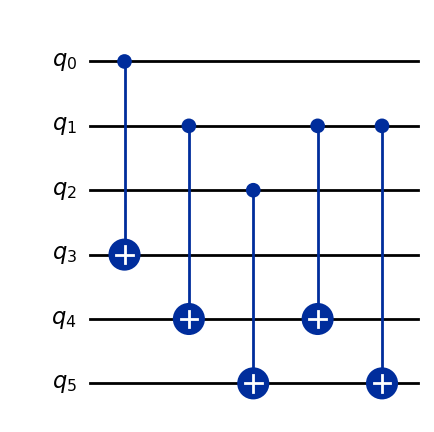

In [3]:
def simon_oracle(s: str) -> QuantumCircuit:
    """Build the 2n-qubit oracle implementing f(x) == f(x XOR s)."""
    n = len(s)
    qc = QuantumCircuit(2 * n, name="oracle")
    s_rev = s[::-1]                      # <-- endianness fix

    # 1. copy the input register onto the output register
    for i in range(n):
        qc.cx(i, n + i)

    # 2. XOR the secret in, creating the two-to-one collision structure
    if "1" in s_rev:
        control = s_rev.index("1")       # any qubit where s has a 1
        for i in range(n):
            if s_rev[i] == "1":
                qc.cx(control, n + i)

    return qc


# Peek at the oracle for s = 110
simon_oracle("110").draw(output="mpl", fold=-1)

## 2. The full circuit — three stages

**Stage 1 — Spread out.** Hadamard gates put the input register into *superposition*: it now represents every possible code at once.

**Stage 2 — Ask the oracle.** The second register fills with every snack at once, and the two codes sharing a snack become *linked*.

**Stage 3 — Fold back.** Hadamard gates again. This causes **interference** — the paired codes overlap and cancel out every possibility that disagrees with the secret. Measure, and you get one clue.

> **The misunderstanding to avoid.** Superposition does *not* mean the computer "tries every answer and picks the right one." Measuring a plain superposition returns a random result and teaches you nothing. The real work is done by **interference** in stage 3 — like noise-cancelling headphones, where a peak meeting a trough cancels to silence.

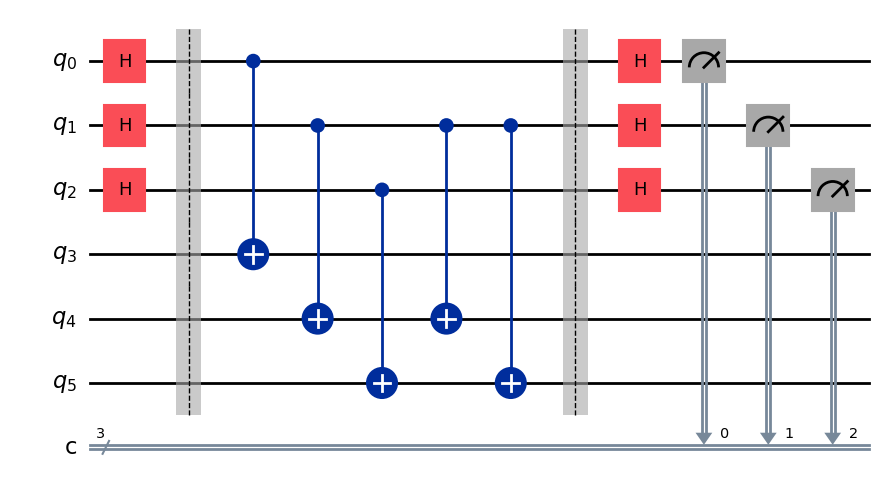

In [4]:
def simon_circuit(s: str) -> QuantumCircuit:
    """Assemble the full three-stage Simon circuit."""
    n = len(s)
    qc = QuantumCircuit(2 * n, n)

    # Stage 1 - spread out
    for i in range(n):
        qc.h(i)
    qc.barrier()

    # Stage 2 - ask the oracle
    qc.compose(simon_oracle(s), inplace=True)
    qc.barrier()

    # Stage 3 - fold back, then look
    for i in range(n):
        qc.h(i)
    qc.measure(range(n), range(n))       # measure only the input register

    return qc


SECRET = "110"
qc = simon_circuit(SECRET)
qc.draw(output="mpl", fold=-1)

## 3. Run it

We run 1024 shots. Watch what comes back: with a 3-bit secret there are 8 possible bitstrings, but **only 4 ever appear**.

That is not luck. Exactly half of all bitstrings are forbidden by the secret — they are the ones where `z · s = 1`, and interference cancels them completely.

Measurement counts: {'001': 242, '111': 264, '000': 252, '110': 266}

4 distinct outcomes out of 8 possible.


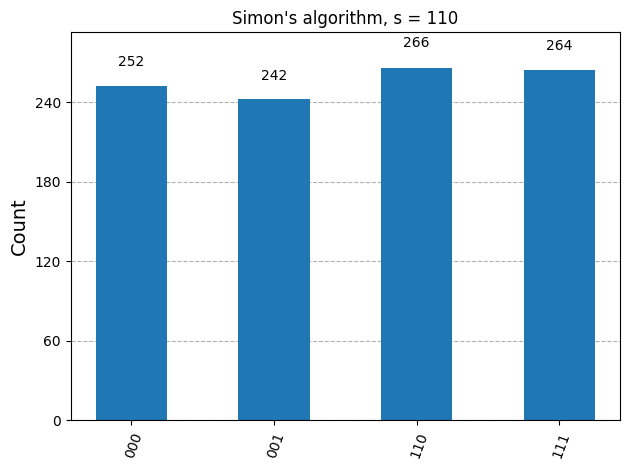

In [5]:
simulator = AerSimulator()
transpiled = transpile(qc, simulator)
counts = simulator.run(transpiled, shots=1024).result().get_counts()

print("Measurement counts:", counts)
print(f"\n{len(counts)} distinct outcomes out of {2**len(SECRET)} possible.")

plot_histogram(counts, title=f"Simon's algorithm, s = {SECRET}")

## 4. The self-check

Every measured `z` **must** satisfy `z · s = 0 (mod 2)`. If any measurement gives an odd dot product, the oracle is broken.

This single test catches the endianness bug immediately. It is worth keeping in any implementation you write.

In [6]:
def dot_mod2(a: str, b: str) -> int:
    """Bitwise dot product of two equal-length bitstrings, modulo 2."""
    return sum(int(x) & int(y) for x, y in zip(a, b)) % 2


print(f"Checking every measurement against s = {SECRET}\n")
print(f"{'z':<8} {'z . s':<8} verdict")
print("-" * 32)

violations = []
for z in sorted(counts):
    d = dot_mod2(z, SECRET)
    if d != 0:
        violations.append(z)
    note = "ok" if d == 0 else "VIOLATION"
    if z == "0" * len(SECRET):
        note = "ok (but useless - no information)"
    print(f"{z:<8} {d:<8} {note}")

print("-" * 32)
if violations:
    print(f"ORACLE BUG: {violations}")
else:
    print("All measurements satisfy z . s == 0. Oracle is sound.")

Checking every measurement against s = 110

z        z . s    verdict
--------------------------------
000      0        ok (but useless - no information)
001      0        ok
110      0        ok
111      0        ok
--------------------------------
All measurements satisfy z . s == 0. Oracle is sound.


### Which bitstrings are forbidden?

Let's confirm the other half never appears.

In [7]:
n = len(SECRET)
all_strings = [format(i, f"0{n}b") for i in range(2 ** n)]

allowed  = [z for z in all_strings if dot_mod2(z, SECRET) == 0]
forbidden = [z for z in all_strings if dot_mod2(z, SECRET) == 1]

print(f"Allowed   (z . s = 0): {allowed}")
print(f"Forbidden (z . s = 1): {forbidden}")
print()
print(f"Actually measured:     {sorted(counts)}")
print()
print("Any forbidden string measured?",
      any(z in counts for z in forbidden))

Allowed   (z . s = 0): ['000', '001', '110', '111']
Forbidden (z . s = 1): ['010', '011', '100', '101']

Actually measured:     ['000', '001', '110', '111']

Any forbidden string measured? False


## 5. The classical half — turning clues into the answer

Each clue `z` is one linear equation about `s`. Collect enough of them and you have a system of simultaneous equations.

Solving it is ordinary school algebra — **Gaussian elimination** — with one twist: every addition is XOR, because we work in even/odd arithmetic (mod 2). So `1 + 1 = 0`.

The all-zeros clue is discarded: it satisfies the equation trivially and carries no information.

Because `s` is a nonzero solution to a homogeneous system, a good set of clues leaves exactly **one free variable**. Set it to 1, back-substitute, and out comes `s`.

In [8]:
def solve_for_s(equations, n):
    """Recover s from clues via Gaussian elimination over GF(2).

    Returns None if the clues are insufficient (gather more runs).
    """
    # Drop the all-zeros clue - always satisfied, carries no information.
    rows = [[int(b) for b in z] for z in equations if "1" in z]
    if not rows:
        return None

    pivots = []
    r = 0
    for c in range(n):
        # find a row at or below r with a leading 1 in column c
        pivot_row = None
        for i in range(r, len(rows)):
            if rows[i][c] == 1:
                pivot_row = i
                break
        if pivot_row is None:
            continue

        rows[r], rows[pivot_row] = rows[pivot_row], rows[r]

        # eliminate column c from every other row - addition is XOR
        for i in range(len(rows)):
            if i != r and rows[i][c] == 1:
                rows[i] = [a ^ b for a, b in zip(rows[i], rows[r])]

        pivots.append(c)
        r += 1

    free = [c for c in range(n) if c not in pivots]
    if len(free) != 1:
        return None                      # under-determined

    f = free[0]
    s = [0] * n
    s[f] = 1
    for i, c in enumerate(pivots):
        s[c] = rows[i][f]

    return "".join(map(str, s))

In [9]:
clues = [z for z in counts if "1" in z]
print("Clues (all-zeros discarded):", clues)

recovered = solve_for_s(clues, len(SECRET))

print()
print(f"Recovered s: {recovered}")
print(f"Actual    s: {SECRET}")
print(f"Match:       {recovered == SECRET}")

Clues (all-zeros discarded): ['001', '111', '110']

Recovered s: 110
Actual    s: 110
Match:       True


## 6. Try your own secret

Change `MY_SECRET` below to any binary string and re-run. Two rules:

- It must contain at least one `1`. An all-zeros secret makes `f` one-to-one rather than two-to-one, so Simon's problem is ill-posed — there is nothing to find.
- Longer secrets need more qubits (`2n` total), so simulation slows down. Keep it under ~8 bits on a laptop.

secret     : 1011
outcomes   : 8 of 16 possible
violations : 0  (oracle sound)
clues      : ['1110', '0100', '1101', '0111', '0011', '1010', '1001']
recovered  : 1011
match      : True


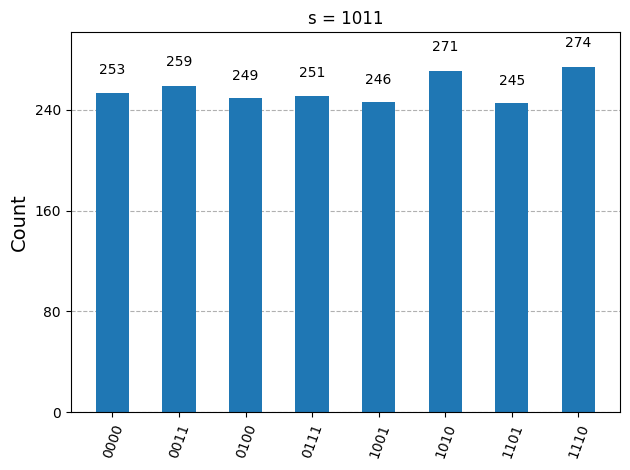

In [10]:
MY_SECRET = "1011"     # <-- change me

def run_simon(secret, shots=2048, show_plot=True):
    """Run the full algorithm end to end."""
    n = len(secret)
    assert "1" in secret, "secret must contain at least one 1"

    qc = simon_circuit(secret)
    sim = AerSimulator()
    counts = sim.run(transpile(qc, sim), shots=shots).result().get_counts()

    violations = [z for z in counts if dot_mod2(z, secret) != 0]
    clues = [z for z in counts if "1" in z]
    recovered = solve_for_s(clues, n)

    print(f"secret     : {secret}")
    print(f"outcomes   : {len(counts)} of {2**n} possible")
    print(f"violations : {len(violations)}  {'(oracle sound)' if not violations else violations}")
    print(f"clues      : {clues}")
    print(f"recovered  : {recovered}")
    print(f"match      : {recovered == secret}")

    if show_plot:
        return plot_histogram(counts, title=f"s = {secret}")


run_simon(MY_SECRET)

## 7. Self-test across many secrets

The real proof that the implementation is correct: run it against secrets of varying length and confirm **zero violations** every time.

In [11]:
secrets = ["11", "01", "110", "101", "011", "100", "1011", "1101", "10110"]

print(f"{'secret':<10} {'recovered':<12} {'violations':<12} result")
print("-" * 48)

failures = 0
sim = AerSimulator()
for s in secrets:
    qc_t = simon_circuit(s)
    c = sim.run(transpile(qc_t, sim), shots=2048).result().get_counts()

    v = [z for z in c if dot_mod2(z, s) != 0]
    rec = solve_for_s([z for z in c if "1" in z], len(s))

    ok = (rec == s) and not v
    failures += (not ok)
    print(f"{s:<10} {str(rec):<12} {len(v):<12} {'PASS' if ok else 'FAIL'}")

print("-" * 48)
print(f"{len(secrets) - failures}/{len(secrets)} passed")

secret     recovered    violations   result
------------------------------------------------


11         11           0            PASS
01         01           0            PASS


110        110          0            PASS


101        101          0            PASS


011        011          0            PASS


100        100          0            PASS


1011       1011         0            PASS


1101       1101         0            PASS


10110      10110        0            PASS
------------------------------------------------
9/9 passed


## 8. Why Simon's algorithm matters

| Reason | Explanation |
|---|---|
| **First exponential separation** | Deutsch-Jozsa and Bernstein-Vazirani showed quantum computers could be faster. Simon's was the first to show they could be *exponentially* faster than any classical method, including randomized ones. |
| **It inspired Shor's algorithm** | Peter Shor read Simon's result and recognized the same structure in factoring. Shor's algorithm — the one that threatens RSA — is a direct descendant. |
| **It established the template** | Quantum sampling followed by classical post-processing. Almost every major quantum algorithm since follows this shape. |
| **Hidden subgroup problem** | Simon's secret string is a simple case of a broad mathematical pattern that also covers factoring and discrete logarithms. |
| **Benchmarking** | The answer is known in advance, so it makes a clean test of whether real quantum hardware is behaving. |

### The honest caveat

Nobody has a practical vending machine to interrogate. Simon's problem is **artificial** — constructed to demonstrate a point. Its value is that the point it demonstrates turned out to be enormous.

---

### Simon's vs Bernstein-Vazirani

| | Bernstein-Vazirani | Simon's |
|---|---|---|
| Registers | `n` qubits + 1 ancilla | `n` qubits + `n` qubits |
| Oracle output | One bit | An `n`-bit string |
| Runs needed | Exactly 1 | About `n` |
| Classical post-processing | None — read the answer directly | Solve a system of equations |
| Classical cost | `n` queries (linear) | $2^{n/2}$ (exponential) |
| Speedup | Modest | **Exponential** |

The structural difference: Bernstein-Vazirani's oracle answers with a *single bit*, so one clever query extracts everything. Simon's oracle answers with a whole *string*, hiding the secret in a **relationship between inputs** rather than in the output itself. That is why you need several runs and some algebra.

---

## References

- Simon, D. R. — *On the Power of Quantum Computation*, SIAM Journal on Computing (1997)
- Shor, P. W. — *Algorithms for Quantum Computation: Discrete Logarithms and Factoring* (1994)
- Qiskit documentation — [docs.quantum.ibm.com](https://docs.quantum.ibm.com)

---

*© 2026 David Grunwald. All rights reserved.*